# Vitals and Lab Values Analysis
## Goal: Understand vital signs and lab measurements for state space design

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Data

In [2]:
data_dir = Path('../artifacts/cleaned')

# Load event tables
chartevents = pd.read_parquet(data_dir / 'CHARTEVENTS.parquet')
labevents = pd.read_parquet(data_dir / 'LABEVENTS.parquet')
d_items = pd.read_parquet(data_dir / 'D_ITEMS.parquet')
d_labitems = pd.read_parquet(data_dir / 'D_LABITEMS.parquet')
icustays = pd.read_parquet(data_dir / 'ICUSTAYS.parquet')

print(f"Chart Events: {len(chartevents):,}")
print(f"Lab Events: {len(labevents):,}")
print(f"Unique chart items: {chartevents['itemid'].nunique():,}")
print(f"Unique lab items: {labevents['itemid'].nunique():,}")

Chart Events: 758,355
Lab Events: 76,074
Unique chart items: 1,679
Unique lab items: 439


## 2. Most Common Chart Items (Vitals)

In [3]:
# Merge with item descriptions
chart_with_labels = chartevents.merge(
    d_items[['itemid', 'label', 'category', 'unitname']], 
    on='itemid', 
    how='left'
)

# Count by item
chart_counts = chart_with_labels.groupby(['itemid', 'label', 'category']).size().reset_index(name='count')
chart_counts = chart_counts.sort_values('count', ascending=False)

print("Top 20 Most Frequent Chart Items:")
print(chart_counts.head(20).to_string(index=False))

Top 20 Most Frequent Chart Items:
 itemid                                 label                  category  count
 220045                            Heart Rate       Routine Vital Signs   8094
 220210                      Respiratory Rate               Respiratory   8056
 220277           O2 saturation pulseoxymetry               Respiratory   8053
 220048                          Heart Rhythm       Routine Vital Signs   7414
 224650                         Ectopy Type 1       Routine Vital Signs   6962
 220181      Non Invasive Blood Pressure mean       Routine Vital Signs   4895
 220179  Non Invasive Blood Pressure systolic       Routine Vital Signs   4884
 220180 Non Invasive Blood Pressure diastolic       Routine Vital Signs   4879
 227969                   Safety Measures_U_1 Restraint/Support Systems   3451
 220052          Arterial Blood Pressure mean       Routine Vital Signs   3029
 220050      Arterial Blood Pressure systolic       Routine Vital Signs   3018
 220051     Arteri

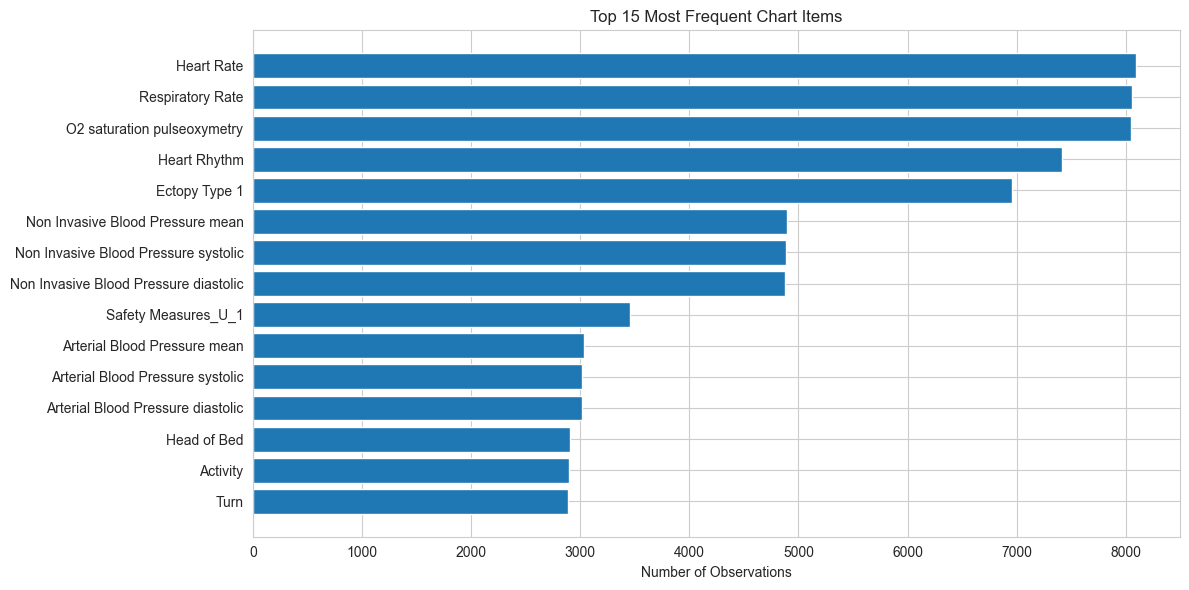

In [4]:
# Visualize top items
top_items = chart_counts.head(15)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_items)), top_items['count'])
plt.yticks(range(len(top_items)), top_items['label'])
plt.xlabel('Number of Observations')
plt.title('Top 15 Most Frequent Chart Items')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Key Vital Signs Analysis
### Focus on common vitals: Heart Rate, Blood Pressure, SpO2, Temperature, Respiratory Rate

In [5]:
# Common vital sign keywords
vital_keywords = {
    'Heart Rate': ['heart rate', 'hr'],
    'Blood Pressure': ['blood pressure', 'bp', 'arterial', 'systolic', 'diastolic', 'mean'],
    'SpO2': ['spo2', 'o2 sat', 'oxygen saturation'],
    'Temperature': ['temperature', 'temp'],
    'Respiratory Rate': ['respiratory rate', 'resp rate', 'rr'],
    'GCS': ['gcs', 'glasgow'],
}

def categorize_vital(label):
    if pd.isna(label):
        return 'Other'
    label_lower = label.lower()
    for category, keywords in vital_keywords.items():
        if any(kw in label_lower for kw in keywords):
            return category
    return 'Other'

chart_with_labels['vital_category'] = chart_with_labels['label'].apply(categorize_vital)

# Count by vital category
vital_distribution = chart_with_labels['vital_category'].value_counts()
print("\nVital Signs Distribution:")
print(vital_distribution)


Vital Signs Distribution:
vital_category
Other               577974
Blood Pressure       76671
Heart Rate           28676
Respiratory Rate     26168
SpO2                 25903
Temperature          14931
GCS                   8032
Name: count, dtype: int64


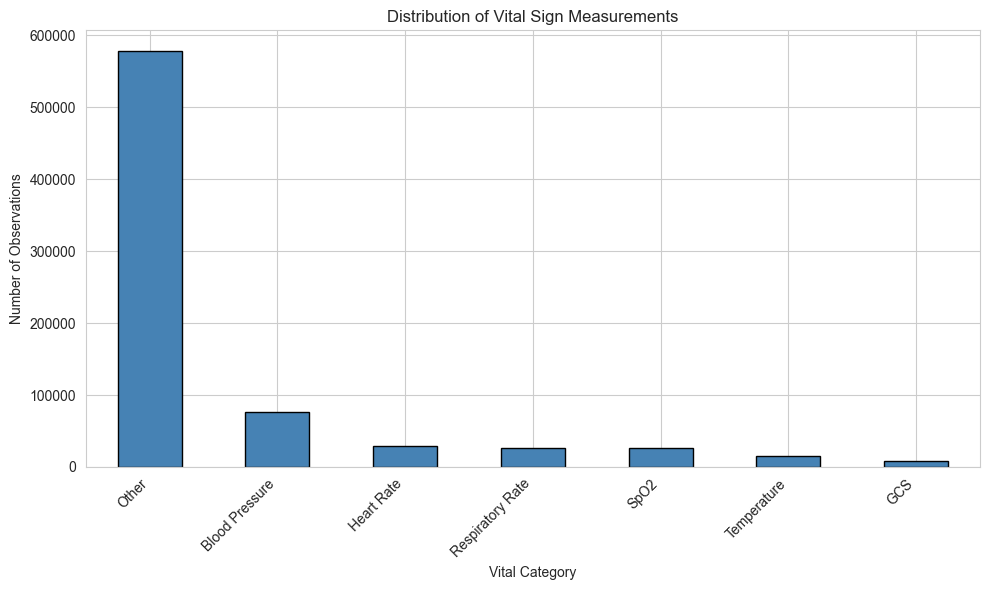

In [6]:
# Visualize vital categories
plt.figure(figsize=(10, 6))
vital_distribution.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Vital Category')
plt.ylabel('Number of Observations')
plt.title('Distribution of Vital Sign Measurements')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Vital Sign Value Distributions

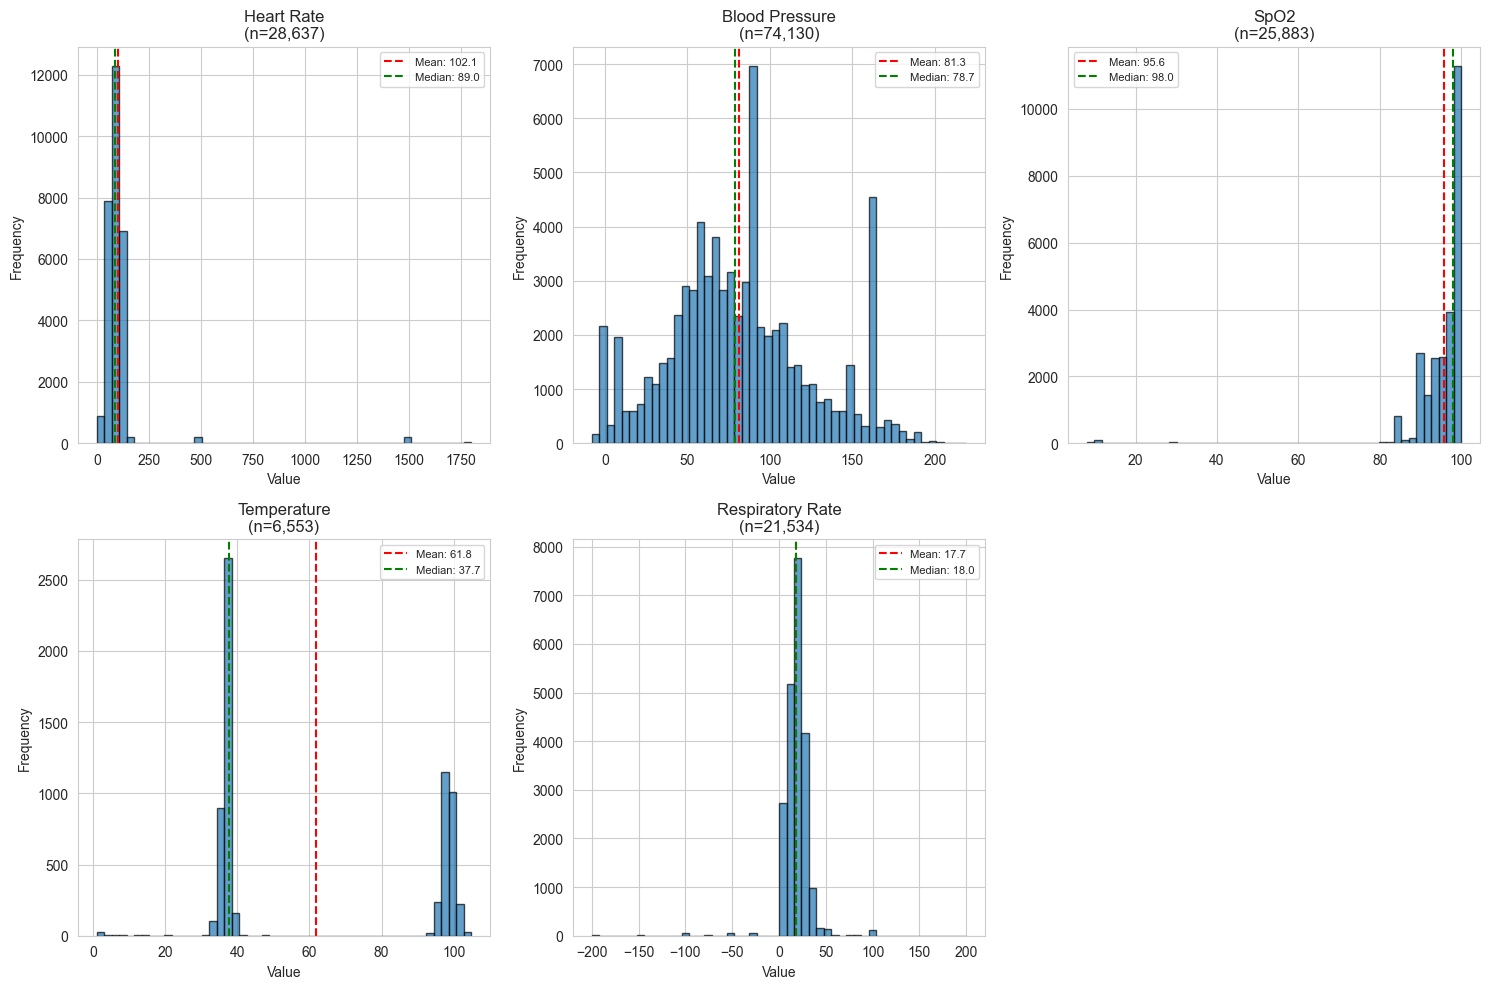

In [7]:
# Analyze numeric values for key vitals
vitals_numeric = chart_with_labels[chart_with_labels['valuenum'].notna()].copy()

# Plot distributions for each vital category
vital_categories = ['Heart Rate', 'Blood Pressure', 'SpO2', 'Temperature', 'Respiratory Rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, vital_cat in enumerate(vital_categories):
    data = vitals_numeric[vitals_numeric['vital_category'] == vital_cat]['valuenum']
    
    if len(data) > 0:
        # Remove extreme outliers (0.1 and 99.9 percentiles)
        lower, upper = data.quantile([0.001, 0.999])
        filtered_data = data[(data >= lower) & (data <= upper)]
        
        axes[idx].hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{vital_cat}\n(n={len(data):,})')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        
        # Add stats
        mean_val = filtered_data.mean()
        median_val = filtered_data.median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
        axes[idx].legend(fontsize=8)

# Remove empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 5. Lab Events Analysis

In [8]:
# Merge with lab item descriptions
lab_with_labels = labevents.merge(
    d_labitems[['itemid', 'label', 'fluid', 'category']], 
    on='itemid', 
    how='left'
)

# Most common lab tests
lab_counts = lab_with_labels.groupby(['itemid', 'label', 'fluid']).size().reset_index(name='count')
lab_counts = lab_counts.sort_values('count', ascending=False)

print("Top 20 Most Frequent Lab Tests:")
print(lab_counts.head(20).to_string(index=False))

Top 20 Most Frequent Lab Tests:
 itemid             label fluid  count
  51221        Hematocrit Blood   2317
  50971         Potassium Blood   2279
  50983            Sodium Blood   2185
  50912        Creatinine Blood   2175
  50902          Chloride Blood   2160
  51006     Urea Nitrogen Blood   2158
  50882       Bicarbonate Blood   2151
  50868         Anion Gap Blood   2134
  50931           Glucose Blood   2121
  51265    Platelet Count Blood   2088
  51222        Hemoglobin Blood   2024
  51301 White Blood Cells Blood   2021
  51249              MCHC Blood   2008
  51248               MCH Blood   2007
  51250               MCV Blood   2007
  51279   Red Blood Cells Blood   2007
  51277               RDW Blood   2005
  50960         Magnesium Blood   1918
  50893    Calcium, Total Blood   1757
  50970         Phosphate Blood   1748


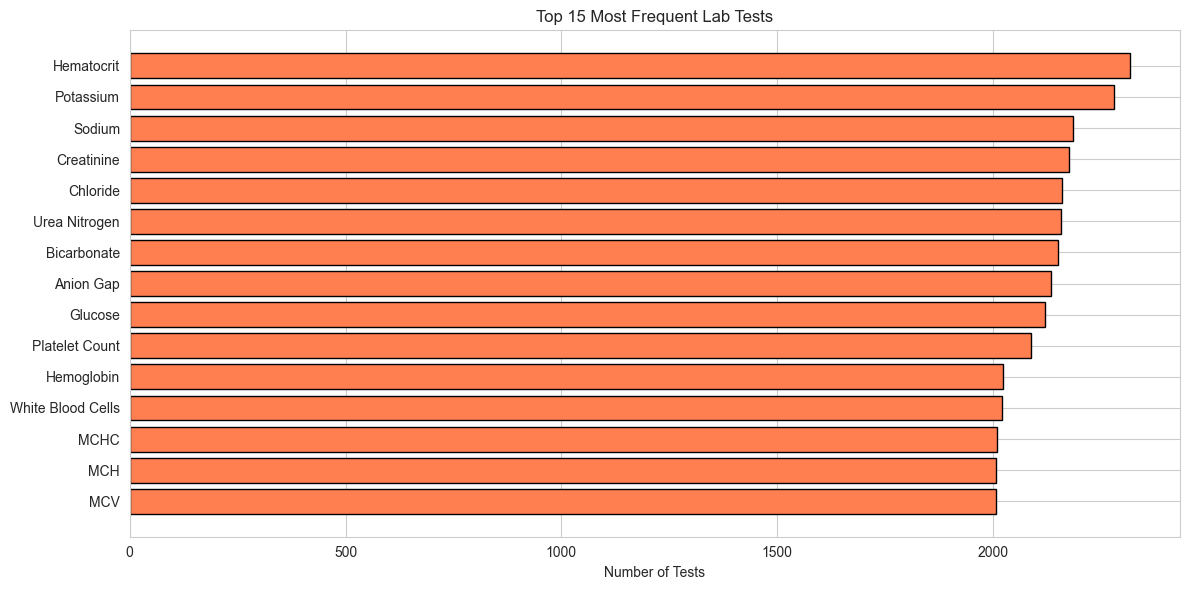

In [9]:
# Visualize top labs
top_labs = lab_counts.head(15)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_labs)), top_labs['count'], color='coral', edgecolor='black')
plt.yticks(range(len(top_labs)), top_labs['label'])
plt.xlabel('Number of Tests')
plt.title('Top 15 Most Frequent Lab Tests')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Data Coverage per ICU Stay


Vital types per ICU stay:
count    133.000000
mean       6.954887
std        0.520266
min        1.000000
25%        7.000000
50%        7.000000
75%        7.000000
max        7.000000
Name: vital_category, dtype: float64


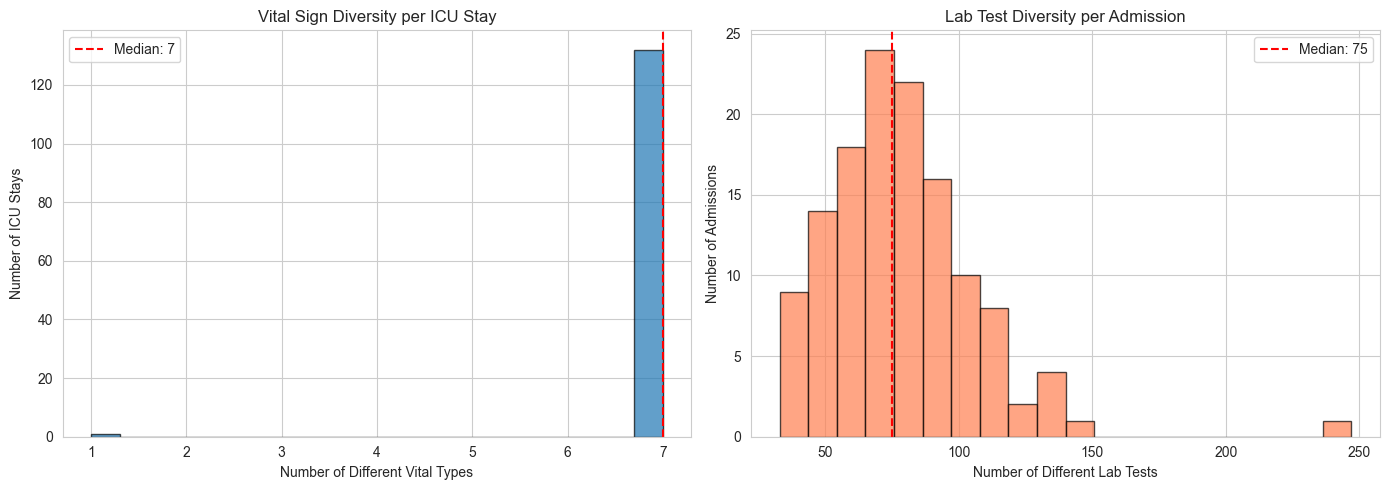

In [10]:
# For each ICU stay, count how many different vital types are recorded
vitals_per_stay = chart_with_labels.groupby('icustay_id')['vital_category'].nunique()
labs_per_stay = lab_with_labels.groupby(['hadm_id'])['itemid'].nunique()

print("\nVital types per ICU stay:")
print(vitals_per_stay.describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vitals_per_stay, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Different Vital Types')
axes[0].set_ylabel('Number of ICU Stays')
axes[0].set_title('Vital Sign Diversity per ICU Stay')
axes[0].axvline(vitals_per_stay.median(), color='red', linestyle='--', label=f'Median: {vitals_per_stay.median():.0f}')
axes[0].legend()

axes[1].hist(labs_per_stay, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Number of Different Lab Tests')
axes[1].set_ylabel('Number of Admissions')
axes[1].set_title('Lab Test Diversity per Admission')
axes[1].axvline(labs_per_stay.median(), color='red', linestyle='--', label=f'Median: {labs_per_stay.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Missing Data Patterns

In [11]:
# Analyze missing numeric values in chart events
missing_numeric = chart_with_labels['valuenum'].isna().sum()
total_charts = len(chart_with_labels)

print(f"\nChart Events with missing numeric values: {missing_numeric:,} / {total_charts:,} ({missing_numeric/total_charts*100:.1f}%)")

# Missing by vital category
missing_by_vital = chart_with_labels.groupby('vital_category').apply(
    lambda x: (x['valuenum'].isna().sum() / len(x) * 100)
).sort_values(ascending=False)

print("\nMissing numeric values by vital category (%)")
print(missing_by_vital)

# Lab events missing
missing_lab_numeric = lab_with_labels['valuenum'].isna().sum()
total_labs = len(lab_with_labels)
print(f"\nLab Events with missing numeric values: {missing_lab_numeric:,} / {total_labs:,} ({missing_lab_numeric/total_labs*100:.1f}%)")


Chart Events with missing numeric values: 434,471 / 758,355 (57.3%)

Missing numeric values by vital category (%)
vital_category
Other               72.469869
Temperature         56.111446
Respiratory Rate    17.708652
Blood Pressure       3.314161
Heart Rate           0.136002
SpO2                 0.077211
GCS                  0.024900
dtype: float64

Lab Events with missing numeric values: 9,044 / 76,074 (11.9%)


## 8. Recommended State Space Features

Based on this analysis, here are recommendations for the RL state space:

In [12]:
# Identify most reliable vitals (high frequency, low missingness)
vital_stats = chart_with_labels[chart_with_labels['vital_category'] != 'Other'].groupby('vital_category').agg({
    'valuenum': ['count', lambda x: x.notna().sum()],
    'icustay_id': 'nunique'
})

vital_stats.columns = ['total_obs', 'with_numeric', 'icu_stays_covered']
vital_stats['completeness'] = (vital_stats['with_numeric'] / vital_stats['total_obs'] * 100).round(1)
vital_stats['avg_per_stay'] = (vital_stats['total_obs'] / vital_stats['icu_stays_covered']).round(1)
vital_stats = vital_stats.sort_values('total_obs', ascending=False)

print("\n=" * 80)
print("RECOMMENDED VITAL SIGNS FOR STATE SPACE")
print("=" * 80)
print(vital_stats)

# Identify top labs
lab_stats = lab_with_labels[lab_with_labels['valuenum'].notna()].groupby('label').agg({
    'valuenum': 'count',
    'hadm_id': 'nunique'
}).reset_index()
lab_stats.columns = ['lab_name', 'total_obs', 'admissions_covered']
lab_stats = lab_stats.sort_values('total_obs', ascending=False).head(10)

print("\n=" * 80)
print("RECOMMENDED LAB VALUES FOR STATE SPACE (Top 10)")
print("=" * 80)
print(lab_stats.to_string(index=False))


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
RECOMMENDED VITAL SIGNS FOR STATE SPACE
                  total_obs  with_numeric  icu_stays_covered  completeness  \
vital_category                                                               
Blood Pressure        74130         74130                132         100.0   
Heart Rate            28637         28637                132         100.0   
SpO2                  25883         25883                132         100.0   
Respiratory Rate      21534         21534                132         100.0   
GCS                    8030          8030                132         100.0   
Temperature            6553          6553                132         100.0   

                  avg_per_stay  
vital_category                  
Blood Pressure           561.6  
Heart Rate               216.9  
SpO2                     196.1  
Respirato

## Key Insights

1. **Vital Signs**: Focus on the most frequently recorded vitals with good completeness
2. **Lab Values**: Select top 10-15 labs that are commonly ordered in ICU
3. **Missing Data Strategy**: Need forward-fill or carry-forward for hourly aggregation
4. **State Dimensionality**: ~15-20 features (vitals + labs + demographics)

## Next Steps
- Design hourly aggregation pipeline
- Handle irregular sampling with forward-fill
- Normalize features (z-score or min-max)
- Create feature engineering module